# Article Analysis

Este notebook lê apenas os artefatos salvos pelos scripts de treino e gera tabelas e gráficos para o trabalho.

In [7]:
from pathlib import Path
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RUN_ROOT = Path('/Users/voymesquita/Documents/mestrado/trabalho/computational-linear-algebra-lora/cla_lora_runs')
FULL_FINETUNE_ROOT = Path('/Users/voymesquita/Documents/mestrado/trabalho/computational-linear-algebra-lora/outputs/cla_lora_runs/full_finetune')
RUN_NAMES = {
    'full_finetune': FULL_FINETUNE_ROOT,
    'lora': RUN_ROOT/'lora_session'/'lora/',
    'adalora': RUN_ROOT/'adalora_session'/'adalora/',
}
K = 4


In [8]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def latest_run_dir(method):
    method_dir = RUN_NAMES[method]
    run_dirs = [path for path in method_dir.iterdir() if path.is_dir()]
    return sorted(run_dirs)[-1]

def method_has_runs(method):
    method_dir = RUN_NAMES[method]
    return method_dir is not None and method_dir.exists() and any(path.is_dir() for path in method_dir.iterdir())

def load_run(method):
    run_dir = latest_run_dir(method)
    return {
        'run_dir': run_dir,
        'config': load_json(run_dir / 'config.json'),
        'summary': load_json(run_dir / 'summary.json'),
        'history': pd.read_csv(run_dir / 'train_history.csv'),
        'deltas': torch.load(run_dir / 'target_deltas.pt', map_location='cpu'),
        'svdvals': torch.load(run_dir / 'target_svdvals.pt', map_location='cpu'),
        'layer_stats': load_json(run_dir / 'layer_stats.json'),
    }

def comparison_history_test(history):
    if 'legacy_test_loss' in history.columns:
        return history['legacy_test_loss']
    return history['test_loss']

def comparison_summary_test(summary):
    return summary.get('final_legacy_test_loss', summary['final_test_loss'])

def corrected_history_test(history):
    if 'test_loss' in history.columns:
        return history['test_loss']
    return None

def corrected_summary_test(summary):
    return summary.get('final_test_loss')

def principal_subspace(delta, side, k):
    u, s, vh = torch.linalg.svd(delta.float(), full_matrices=False)
    if s.numel() == 0:
        return None
    rank = min(k, s.numel())
    if side == 'left':
        return u[:, :rank]
    return vh[:rank, :].T

def subspace_similarity(delta_ref, delta_cmp, k):
    metrics = {}
    for side in ['left', 'right']:
        basis_ref = principal_subspace(delta_ref, side, k)
        basis_cmp = principal_subspace(delta_cmp, side, k)
        gram = basis_ref.T @ basis_cmp
        cosines = torch.linalg.svdvals(gram).clamp(0.0, 1.0)
        angles = torch.rad2deg(torch.acos(cosines))
        overlap = torch.linalg.matrix_norm(gram, ord='fro').item() ** 2 / gram.shape[0]
        metrics[f'{side}_mean_cosine'] = cosines.mean().item()
        metrics[f'{side}_max_angle_deg'] = angles.max().item()
        metrics[f'{side}_overlap'] = overlap
    return metrics


In [10]:
runs = {method: load_run(method) for method in RUN_NAMES if method_has_runs(method)}
list(runs.keys())


PosixPath('/Users/voymesquita/Documents/mestrado/trabalho/computational-linear-algebra-lora/cla_lora_runs/lora_session/lora/20260616_212836')

In [11]:
summary_rows = []
for method, run in runs.items():
    summary = run['summary']
    summary_rows.append({
        'method': method,
        'trainable_params': summary['trainable_params'],
        'trainable_pct': summary['trainable_pct'],
        'comparison_final_test_loss': comparison_summary_test(summary),
        'total_time_sec': summary['total_time_sec'],
    })
pd.DataFrame(summary_rows)


,method,trainable_params,trainable_pct,final_train_loss,final_test_loss,total_time_sec
0,lora,147456,0.118356,2.236503,2.025373,288.484335


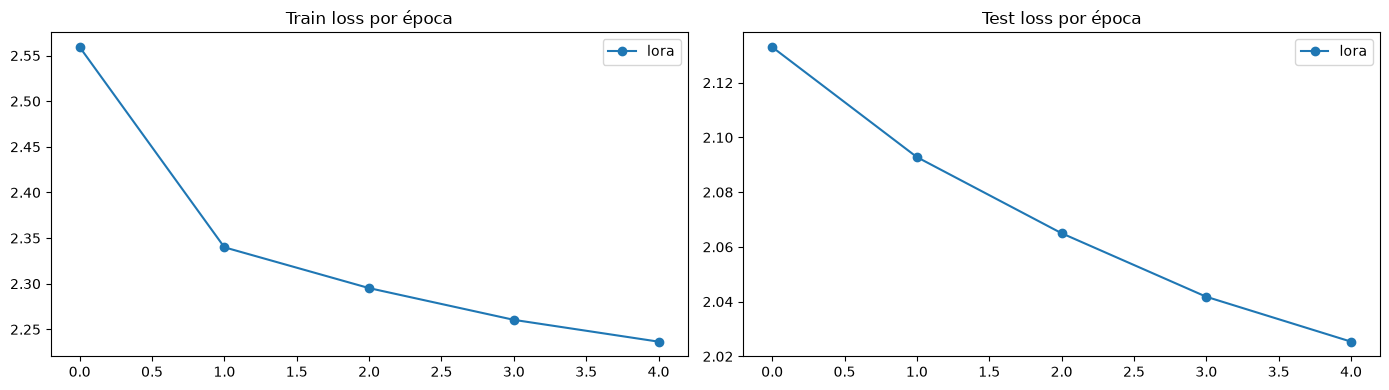

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
for method, run in runs.items():
    history = run['history']
    ax.plot(history['epoch'], comparison_history_test(history), marker='o', label=method)
ax.set_title('Test loss comparavel por epoca')
ax.set_xlabel('Epoca')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()


In [ ]:
if 'full_finetune' in runs:
    full_summary = runs['full_finetune']['summary']
    full_history = runs['full_finetune']['history']
    display(pd.DataFrame([{
        'method': 'full_finetune',
        'final_train_loss_corrigida': full_summary['final_train_loss'],
        'final_test_loss_corrigida': corrected_summary_test(full_summary),
        'final_legacy_test_loss': comparison_summary_test(full_summary),
        'final_legacy_online_train_loss': full_summary.get('final_legacy_online_train_loss'),
    }]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(full_history['epoch'], full_history['train_loss'], marker='o')
    axes[1].plot(full_history['epoch'], corrected_history_test(full_history), marker='o')
    axes[0].set_title('Full fine-tuning: train loss corrigida')
    axes[1].set_title('Full fine-tuning: test loss corrigida')
    axes[0].set_xlabel('Epoca')
    axes[1].set_xlabel('Epoca')
    axes[0].set_ylabel('Loss')
    axes[1].set_ylabel('Loss')
    plt.tight_layout()
else:
    print('Nenhum run de full_finetune encontrado em outputs/cla_lora_runs/full_finetune.')


In [16]:
attention_layers = sorted([
    name for name in runs['lora']['deltas'].keys()
    if '.attn.c_attn' in name
])
attention_layers[:3]

['transformer.h.0.attn.c_attn',
 'transformer.h.1.attn.c_attn',
 'transformer.h.10.attn.c_attn']

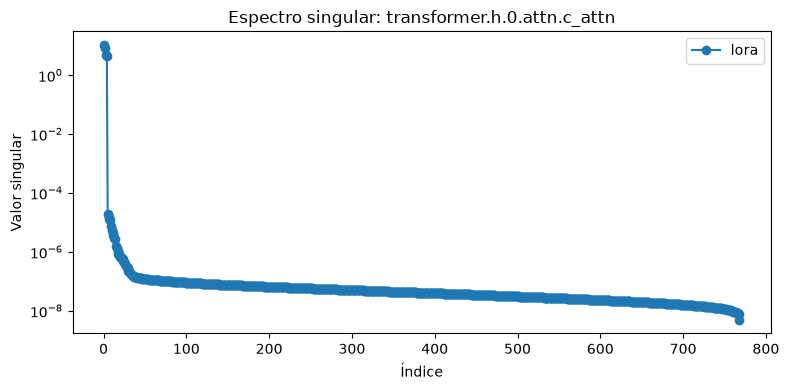

In [17]:
layer_name = attention_layers[0]
plt.figure(figsize=(8, 4))
for method, run in runs.items():
    svdvals = run['svdvals'][layer_name]
    plt.plot(range(1, len(svdvals) + 1), svdvals.numpy(), marker='o', label=method)
plt.yscale('log')
plt.title(f'Espectro singular: {layer_name}')
plt.xlabel('Índice')
plt.ylabel('Valor singular')
plt.legend()
plt.tight_layout()

In [18]:
svd_rows = []
for method, run in runs.items():
    for layer_name, stats in run['layer_stats'].items():
        if '.attn.c_attn' in layer_name:
            svd_rows.append({
                'method': method,
                'layer': layer_name,
                'stable_rank': stats['stable_rank'],
                'energy_90_rank': stats['energy_90_rank'],
                'energy_95_rank': stats['energy_95_rank'],
            })
pd.DataFrame(svd_rows).head()

,method,layer,stable_rank,energy_90_rank,energy_95_rank
0,lora,transformer.h.0.attn.c_attn,1.956153,3,4
1,lora,transformer.h.1.attn.c_attn,2.471848,4,4
2,lora,transformer.h.2.attn.c_attn,2.253442,3,4
3,lora,transformer.h.3.attn.c_attn,2.652706,4,4
4,lora,transformer.h.4.attn.c_attn,2.507056,4,4


In [20]:
similarity_rows = []
for method in ['lora', 'adalora']:
    for layer_name in attention_layers:
        metrics = subspace_similarity(
            runs['lora']['deltas'][layer_name],
            runs[method]['deltas'][layer_name],
            K,
        )
        similarity_rows.append({
            'method': method,
            'layer': layer_name,
            **metrics,
        })
pd.DataFrame(similarity_rows).head()

KeyError: 'adalora'

In [ ]:
adalora_mlp_rows = []
for layer_name, stats in runs['adalora']['layer_stats'].items():
    if '.mlp.' in layer_name:
        adalora_mlp_rows.append({'layer': layer_name, **stats})
pd.DataFrame(adalora_mlp_rows).head()